# 02 — Xây dựng và kiểm tra đặc trưng kỹ thuật

Notebook này làm ba việc:

1. Tính bộ chỉ báo kỹ thuật và **vẽ ra để kiểm tra bằng mắt** — cách nhanh nhất
   phát hiện lỗi lệch một phiên.
2. Kiểm tra **tính nhân quả**: giá trị tại thời điểm `t` chỉ được tính từ dữ liệu
   ở các thời điểm `≤ t`.
3. Soi **ma trận tương quan** để loại các đặc trưng trùng lặp thông tin.

> Hai quy ước của `pipeline/technicalIndicators.py`:
> **(1)** mọi hàm chỉ nhìn về quá khứ; **(2)** mọi hàm trả về dãy cùng độ dài với
> đầu vào, vùng khởi động chưa đủ lịch sử trả về `None`. Nhờ vậy các dãy luôn khớp
> chỉ số và chỉ cần một lần dọn duy nhất.

In [1]:
import os
import sys

# Đưa src/ vào đường dẫn tìm kiếm module để import được các package của dự án.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import matplotlib.pyplot as plt
%matplotlib inline

from libraries import rfPlot
from pipeline import featureBuilder, technicalIndicators, timePreprocess
from utilities import dataLoader, plotStyle

## 1. Cấu hình

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'input', 'VNM.csv')
SYMBOL    = 'VNM'

DATE_COLUMN, OPEN_COLUMN = 'Date', 'Open'
HIGH_COLUMN, LOW_COLUMN  = 'High', 'Low'
CLOSE_COLUMN, VOLUME_COLUMN = 'Close', 'Volume'
NUMERIC_COLUMNS = [OPEN_COLUMN, HIGH_COLUMN, LOW_COLUMN, CLOSE_COLUMN, VOLUME_COLUMN]

SHORT_WINDOW, LONG_WINDOW = 5, 20
RSI_WINDOW, ATR_WINDOW    = 14, 14
BOLLINGER_WINDOW, BOLLINGER_DEVIATIONS = 20, 2.0
MACD_WINDOWS = (12, 26, 9)
CORRELATION_THRESHOLD = 0.95

In [3]:
headers, table = dataLoader.load_csv_data(DATA_PATH, verbose=False)
for name in NUMERIC_COLUMNS:
    table[name] = [None if value in (None, '') else float(value)
                   for value in table[name]]
table[DATE_COLUMN] = timePreprocess.parse_date_series(table[DATE_COLUMN])

table = timePreprocess.sort_table_by_column(table, DATE_COLUMN)
table = timePreprocess.remove_duplicate_keys(table, DATE_COLUMN)
for name in NUMERIC_COLUMNS:
    table[name] = timePreprocess.forward_fill_series(table[name], 2)
table, _ = timePreprocess.drop_rows_with_missing(table)

dates  = table[DATE_COLUMN]
close  = table[CLOSE_COLUMN]
high   = table[HIGH_COLUMN]
low    = table[LOW_COLUMN]
volume = table[VOLUME_COLUMN]
print(f'{len(close)} phiên, {dates[0]} → {dates[-1]}')

2587 phiên, 2016-08-22 → 2026-08-21


## 2. Kiểm tra tính nhân quả

Phép thử trực tiếp: cắt chuỗi tại vị trí `k` rồi tính lại chỉ báo trên đoạn đầu.
Nếu hàm chỉ nhìn về quá khứ, giá trị tại mọi vị trí `< k` phải **giống hệt** giá
trị tính trên chuỗi đầy đủ. Sai khác dù nhỏ cũng có nghĩa là chỉ báo đang nhìn
trộm tương lai.

In [4]:
CUT_POSITION = 1000

checks = {
    'simple_moving_average':      lambda s: technicalIndicators.simple_moving_average(s, LONG_WINDOW),
    'exponential_moving_average': lambda s: technicalIndicators.exponential_moving_average(s, LONG_WINDOW),
    'relative_strength_index':    lambda s: technicalIndicators.relative_strength_index(s, RSI_WINDOW),
    'rate_of_change':             lambda s: technicalIndicators.rate_of_change(s, 10),
    'rolling_standard_deviation': lambda s: technicalIndicators.rolling_standard_deviation(s, LONG_WINDOW),
}

print(f"{'Chỉ báo':<30}{'Kết quả':>12}")
print('-' * 42)
for name, function in checks.items():
    full    = function(close)[:CUT_POSITION]
    partial = function(close[:CUT_POSITION])
    identical = all(
        (a is None and b is None) or
        (a is not None and b is not None and abs(a - b) < 1e-9)
        for a, b in zip(full, partial)
    )
    print(f"{name:<30}{'ĐẠT' if identical else 'SAI':>12}")

Chỉ báo                            Kết quả
------------------------------------------
simple_moving_average                  ĐẠT
exponential_moving_average             ĐẠT
relative_strength_index                ĐẠT
rate_of_change                         ĐẠT
rolling_standard_deviation             ĐẠT


## 3. Vẽ chỉ báo để kiểm tra bằng mắt

Đã lưu đồ thị: E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\output\VNM_02_indicators.png


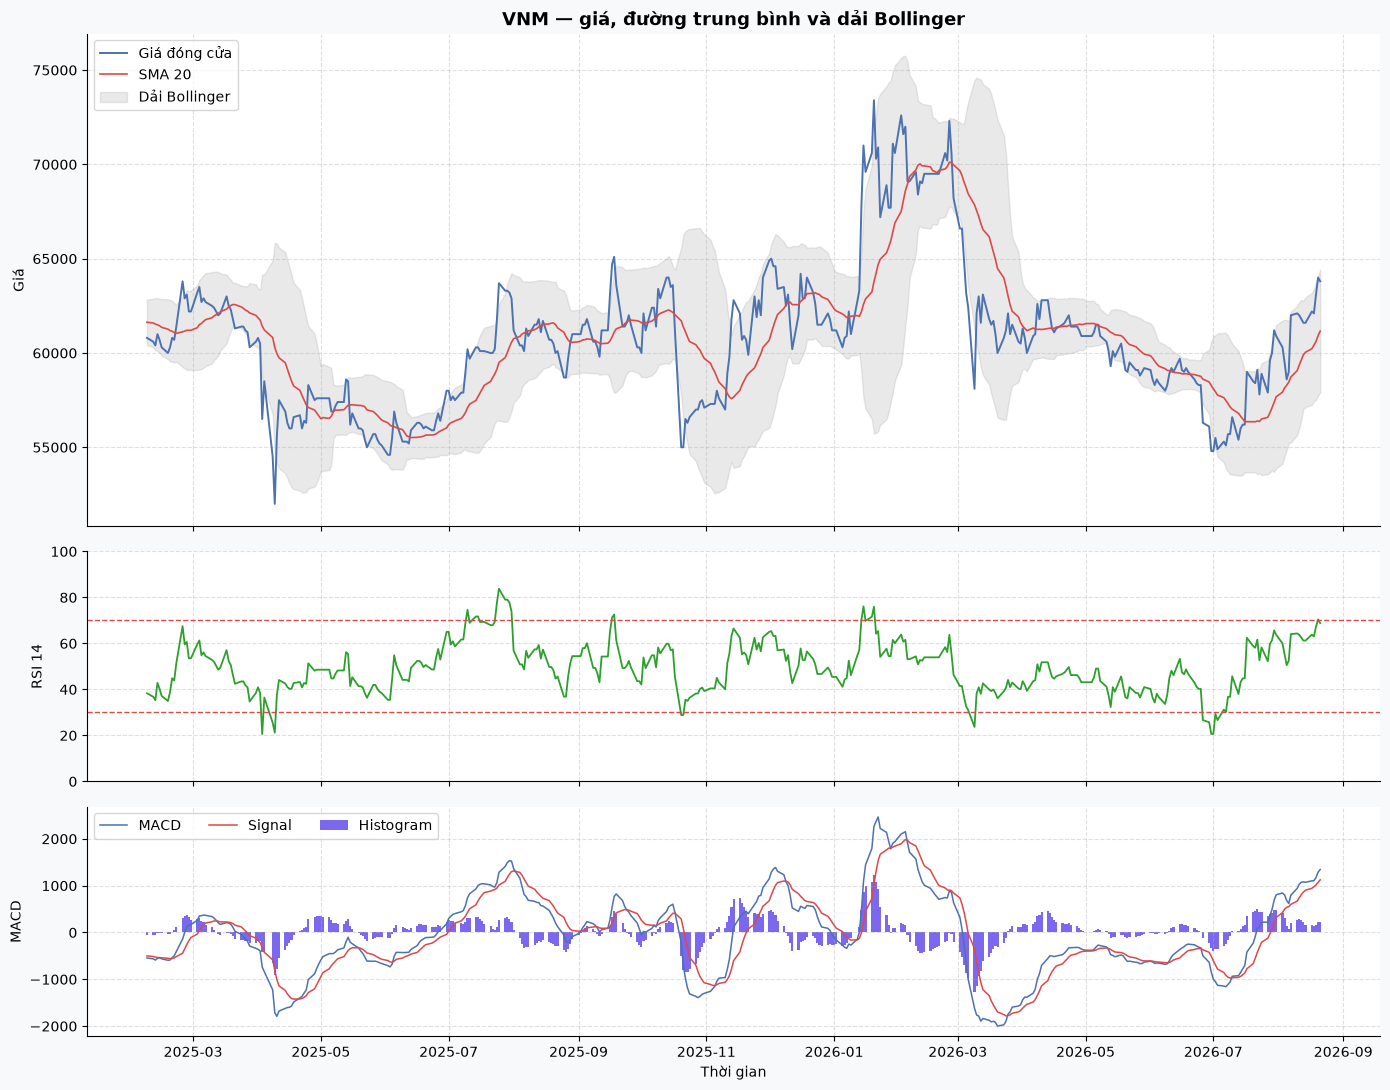

In [5]:
sma_short = technicalIndicators.simple_moving_average(close, SHORT_WINDOW)
sma_long  = technicalIndicators.simple_moving_average(close, LONG_WINDOW)
middle, upper, lower, percent_b, bandwidth = technicalIndicators.bollinger_bands(
    close, BOLLINGER_WINDOW, BOLLINGER_DEVIATIONS)
rsi = technicalIndicators.relative_strength_index(close, RSI_WINDOW)
macd_line, macd_signal, macd_histogram = \
    technicalIndicators.moving_average_convergence_divergence(close, *MACD_WINDOWS)

WINDOW_START, WINDOW_END = -400, None
segment = slice(WINDOW_START, WINDOW_END)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.4, 1.4]})
fig.patch.set_facecolor(plotStyle.FIGURE_BG_COLOR)

axes[0].plot(dates[segment], close[segment], color=plotStyle.POINT_COLOR,
             linewidth=1.4, label='Giá đóng cửa')
axes[0].plot(dates[segment], sma_long[segment], color=plotStyle.LINE_COLOR,
             linewidth=1.2, label=f'SMA {LONG_WINDOW}')
axes[0].fill_between(dates[segment], lower[segment], upper[segment],
                     color=plotStyle.NEUTRAL_COLOR, alpha=0.18,
                     label='Dải Bollinger')
axes[0].set_ylabel('Giá')
axes[0].set_title(f'{SYMBOL} — giá, đường trung bình và dải Bollinger',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')
plotStyle.apply_axes_style(axes[0])

axes[1].plot(dates[segment], rsi[segment], color=plotStyle.RESIDUAL_COLOR, linewidth=1.3)
axes[1].axhline(70, color=plotStyle.LINE_COLOR, linestyle='--', linewidth=1)
axes[1].axhline(30, color=plotStyle.LINE_COLOR, linestyle='--', linewidth=1)
axes[1].set_ylabel(f'RSI {RSI_WINDOW}')
axes[1].set_ylim(0, 100)
plotStyle.apply_axes_style(axes[1])

axes[2].bar(dates[segment], [0.0 if v is None else v for v in macd_histogram[segment]],
            color=plotStyle.BAR_COLOR, width=1.0, label='Histogram')
axes[2].plot(dates[segment], macd_line[segment], color=plotStyle.POINT_COLOR,
             linewidth=1.1, label='MACD')
axes[2].plot(dates[segment], macd_signal[segment], color=plotStyle.LINE_COLOR,
             linewidth=1.1, label='Signal')
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Thời gian')
axes[2].legend(loc='upper left', ncol=3)
plotStyle.apply_axes_style(axes[2])

fig.tight_layout()
plotStyle.save_figure(fig, f'{SYMBOL}_02_indicators.png')
plt.show()

## 4. Dựng bảng đặc trưng bằng bản đặc tả

Thay vì gọi từng hàm chỉ báo, ta mô tả bộ đặc trưng bằng **dữ liệu** rồi để
`featureBuilder` thi hành. Đây chính là bản đặc tả nằm trong
`config/classification.json`, nhờ đó notebook và script chạy tạo ra **cùng một bộ
đặc trưng**.

In [6]:
import json

with open(os.path.join(PROJECT_ROOT, 'config', 'classification.json'),
          encoding='utf-8') as handle:
    config = json.load(handle)

source_series = {role: table[column]
                 for role, column in config['dataset']['series'].items()}
feature_table, all_series = featureBuilder.build_features(
    config['features'], source_series, verbose=True)

feature_names = sorted(feature_table)
print(f'\nTổng số đặc trưng đưa vào mô hình: {len(feature_names)}')

  returns                  (simple_returns) → ['returns']
  sma_5                    (simple_moving_average) → ['sma_5']
  sma_20                   (simple_moving_average) → ['sma_20']
  close_over_sma5          (ratio_to_moving_average) → ['close_over_sma5']
  close_over_sma10         (ratio_to_moving_average) → ['close_over_sma10']
  close_over_sma20         (ratio_to_moving_average) → ['close_over_sma20']
  close_over_sma50         (ratio_to_moving_average) → ['close_over_sma50']
  close_over_ema12         (ratio_to_moving_average) → ['close_over_ema12']
  sma5_above_sma20         (crossover_indicator) → ['sma5_above_sma20']
  macd                     (macd) → ['macd_line', 'macd_raw', 'macd_signal']
  macd_histogram           (ratio_series) → ['macd_histogram']
  macd_over_signal         (crossover_indicator) → ['macd_over_signal']
  rsi_7                    (relative_strength_index) → ['rsi_7']
  rsi_14                   (relative_strength_index) → ['rsi_14']
  roc_5              

In [7]:
print(f"{'Đặc trưng':<20}{'n':>7}{'thiếu':>8}{'min':>12}{'max':>12}{'trung bình':>13}")
print('-' * 72)
for name in feature_names:
    stats = timePreprocess.describe_series(feature_table[name])
    print(f"{name:<20}{stats['count']:>7}{stats['missing']:>8}"
          f"{stats['minimum']:>12.4f}{stats['maximum']:>12.4f}{stats['mean']:>13.4f}")

Đặc trưng                 n   thiếu         min         max   trung bình
------------------------------------------------------------------------
atr_over_close         2574      13      0.0062      0.0436       0.0180
bollinger_b            2568      19     -0.4424      1.4287       0.4692
bollinger_width        2568      19      0.0116      0.3393       0.0883
close_over_ema12       2576      11      0.8815      1.1338       0.9989
close_over_sma10       2578       9      0.8762      1.1432       0.9992
close_over_sma20       2568      19      0.8367      1.1854       0.9984
close_over_sma5        2583       4      0.8949      1.0998       0.9997
close_over_sma50       2538      49      0.7761      1.2467       0.9958
macd_histogram         2554      33     -0.0220      0.0171       0.0001
macd_over_signal       2554      33      0.0000      1.0000       0.5047
obv_return             2585       2   -196.5642    131.8338      -0.0759
relative_range         2587       0      0.0000    

## 5. Tương quan giữa các đặc trưng

Cặp đặc trưng có `|r|` rất cao gần như mang cùng một thông tin. Với mô hình dựa
trên cây, điều đó ít ảnh hưởng tới độ chính xác nhưng làm **loãng** chỉ số tầm
quan trọng: công trạng bị chia đều cho cả nhóm, khiến chúng cùng tụt hạng.

Đã lưu đồ thị: E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\output\VNM_02_correlation.png


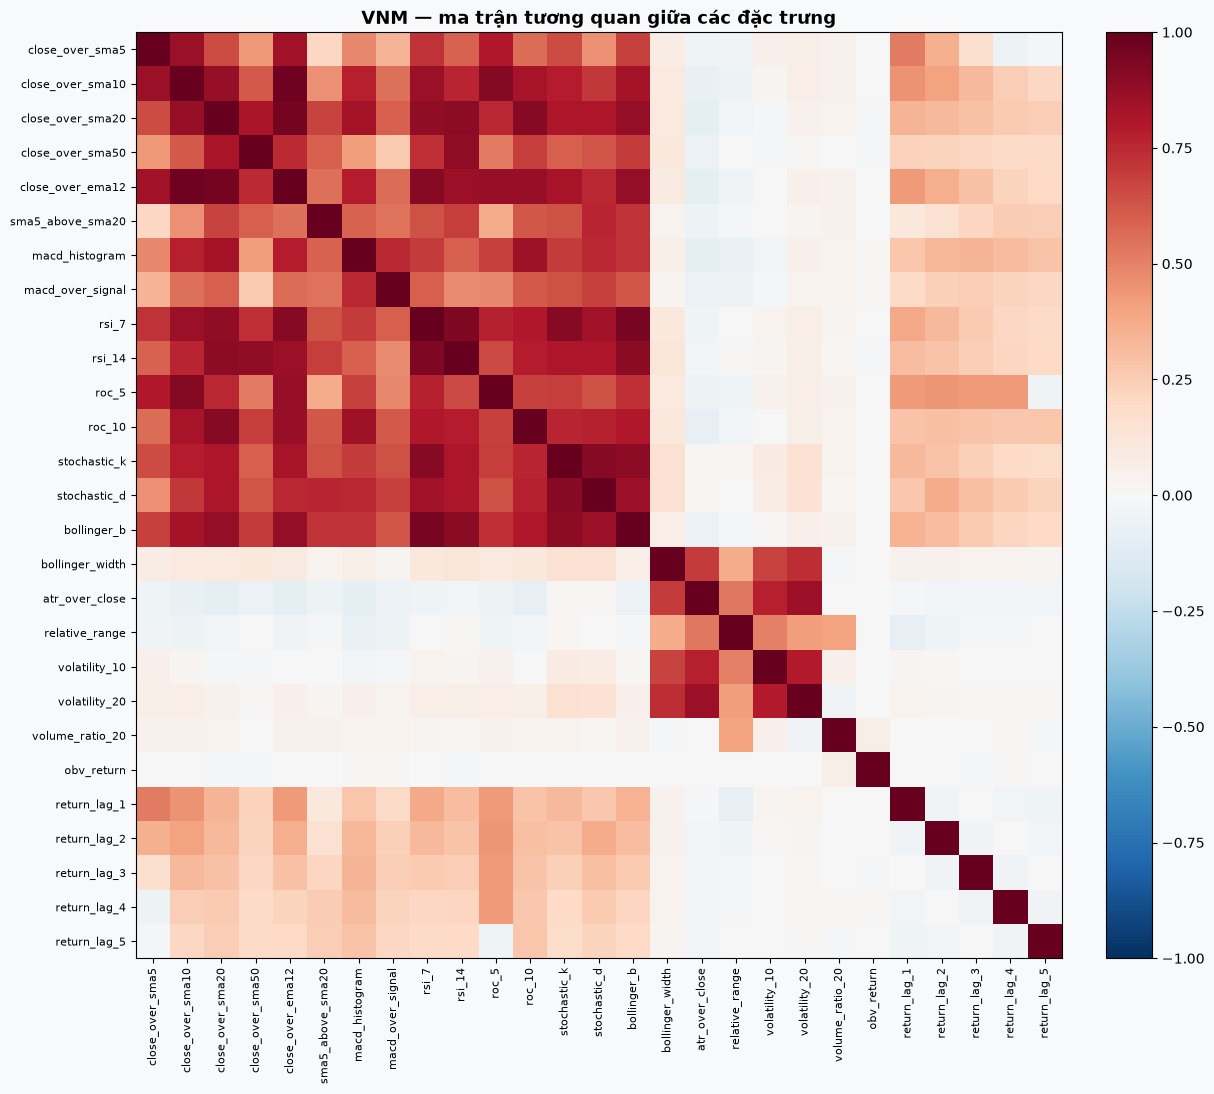

Cặp có |r| > 0.95: 3
  close_over_sma10     ↔ close_over_ema12     r = +0.9696
  close_over_sma20     ↔ close_over_ema12     r = +0.9533
  rsi_7                ↔ bollinger_b          r = +0.9519


In [8]:
column_names, matrix = timePreprocess.calculate_correlation_matrix(feature_table)

rfPlot.plot_correlation_matrix(
    column_names, matrix,
    title=f'{SYMBOL} — ma trận tương quan giữa các đặc trưng',
    filename=f'{SYMBOL}_02_correlation.png',
)
plt.show()

pairs = timePreprocess.find_highly_correlated_pairs(
    feature_table, threshold=CORRELATION_THRESHOLD)
print(f'Cặp có |r| > {CORRELATION_THRESHOLD}: {len(pairs)}')
for first, second, value in pairs:
    print(f'  {first:<20} ↔ {second:<20} r = {value:+.4f}')

## 6. Vùng khởi động bị mất

Chỉ báo có cửa sổ dài nhất quyết định số dòng đầu chuỗi phải bỏ đi. Đây là cái giá
phải trả cho việc dùng lịch sử — và là lý do dữ liệu cần đủ dài.

In [9]:
warmup = max(
    next((index for index, value in enumerate(feature_table[name])
          if value is not None), len(close))
    for name in feature_names
)
print(f'Số dòng đầu bị loại do chưa đủ lịch sử: {warmup}')
print(f'Số mẫu còn lại: {len(close) - warmup} / {len(close)} '
      f'({(len(close) - warmup) / len(close):.1%})')

Số dòng đầu bị loại do chưa đủ lịch sử: 49
Số mẫu còn lại: 2538 / 2587 (98.1%)


## 7. Kết luận

Bộ đặc trưng đã sẵn sàng. Bước tiếp theo:

- [`03_train_classify.ipynb`](03_train_classify.ipynb) — nhánh A, phân loại xu hướng
- [`04_train_regress.ipynb`](04_train_regress.ipynb) — nhánh B, hồi quy tỷ suất